In [4]:
# 1) 한 번만: 압축 풀기
!tar xzf EnglishFnt.tgz -C sample_data/

In [7]:
!pip install "protobuf==3.20.3" tflite-support

In [8]:
# ────────────────────────────────────────────────────────────────
# 0) EnglishFnt에서 D/N/E 데이터셋 자동 구축
# ────────────────────────────────────────────────────────────────
import os
from pathlib import Path
from PIL import Image
import shutil
import random

# 원본 폰트 이미지 경로
FNT_BASE = Path("sample_data/English/Fnt")
OUT_BASE = Path("dataset")
CLASS_MAP = {'Sample014': 'D', 'Sample024': 'N', 'Sample015': 'E'}

# dataset/D, dataset/N, dataset/E 폴더 생성 및 초기화
for c in ['D', 'N', 'E']:
    d = OUT_BASE / c
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

# 클래스별로 파일 복사 (최대 2000장씩 샘플)
for sample, label in CLASS_MAP.items():
    src = FNT_BASE / sample
    dst = OUT_BASE / label
    files = list(src.glob("*.png"))
    random.shuffle(files)
    for i, f in enumerate(files[:2000]):
        img = Image.open(f).convert("L").resize((32,32))
        img.save(dst / f"{label}_{i:04d}.png")

print("✅ EnglishFnt → dataset/D,N,E 자동 구축 완료")

# ────────────────────────────────────────────────────────────────
# 1) Keras 데이터셋 로드 및 증강
# ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE    = (32, 32)
BATCH_SIZE  = 64
EPOCHS      = 20
TFLITE_PATH = "dne_classifier.tflite"
CLASS_NAMES = ["D", "N", "E"]
VALID_SPLIT = 0.2
SEED        = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="training",
    seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="validation",
    seed=SEED
)

normalization = layers.Rescaling(1.0 / 255)
data_augmentation = tf.keras.Sequential([
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomRotation(0.1),
])

def preprocess_train(x, y):
    x = tf.expand_dims(x, -1) if x.shape[-1] != 1 else x
    x = data_augmentation(x)
    x = normalization(x)
    return x, y

train_ds = train_ds.map(preprocess_train).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

# ────────────────────────────────────────────────────────────────
# 2) CNN 모델 정의 및 학습
# ────────────────────────────────────────────────────────────────
def build_dne_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_dne_model(IMG_SIZE + (1,), len(CLASS_NAMES))
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ────────────────────────────────────────────────────────────────
# 3) TFLite 변환 및 저장
# ────────────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)
print(f"✅ 3-class TFLite model saved at '{TFLITE_PATH}'")

# ────────────────────────────────────────────────────────────────
# 4) labels.txt 생성 (메타데이터용)
# ────────────────────────────────────────────────────────────────
with open("labels.txt", "w") as f:
    f.write("D\nN\nE\n")
print("✅ labels.txt 생성 완료")

# ────────────────────────────────────────────────────────────────
# 5) TFLite 메타데이터 포함시키기 (tflite-support 필요)
# ────────────────────────────────────────────────────────────────
try:
    from tflite_support.metadata_writers import image_classifier
    from tflite_support.metadata_writers import writer_utils

    MODEL_PATH = TFLITE_PATH
    LABEL_FILE = "labels.txt"
    EXPORT_MODEL = "dne_classifier_with_metadata.tflite"

    writer = image_classifier.MetadataWriter.create_for_inference(
        writer_utils.load_file(MODEL_PATH),
        input_norm_mean=[0.0],     # 보통 x/255.0로 정규화하면 0.0, 1.0
        input_norm_std=[1.0],
        label_file_paths=[LABEL_FILE]
    )
    metadata_buf = writer.populate()

    with open(EXPORT_MODEL, "wb") as f:
        f.write(metadata_buf)
    print(f"✅ 메타데이터 포함 tflite 저장 완료: {EXPORT_MODEL}")
except ImportError:
    print("❗️ tflite-support가 설치되어 있지 않습니다. pip install tflite-support 먼저 실행하세요.")


✅ EnglishFnt → dataset/D,N,E 자동 구축 완료
Found 3048 files belonging to 3 classes.
Using 2439 files for training.
Found 3048 files belonging to 3 classes.
Using 609 files for validation.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,619 (2.07 MB)

 Trainable params: 543,619 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.6043 - loss: 0.8581 - val_accuracy: 0.9622 - val_loss: 0.1276
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9458 - loss: 0.1678 - val_accuracy: 0.9704 - val_loss: 0.0910
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9590 - loss: 0.1242 - val_accuracy: 0.9688 - val_loss: 0.0739
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9642 - loss: 0.0905 - val_accuracy: 0.9770 - val_loss: 0.0717
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9726 - loss: 0.0784 - val_accuracy: 0.9737 - val_loss: 0.0785
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9594 - loss: 0.1086 - val_accuracy: 0.9754 - val_loss: 0.0690
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9709 - loss: 0.0691 - val_accuracy: 0.9836 - val_loss: 0.0552
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9743 - loss: 0.0726 - val_accuracy: 0.9819 - v

In [10]:
!pip install opencv-python-headless

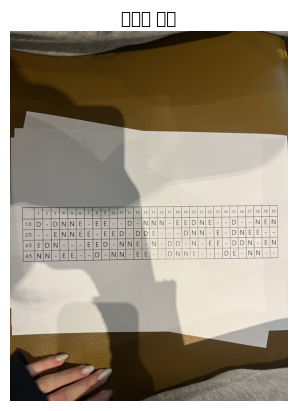

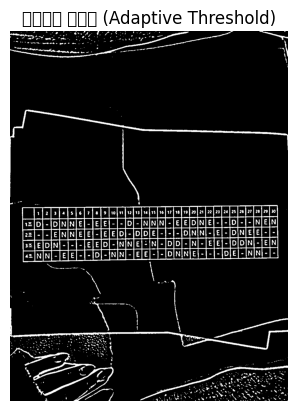

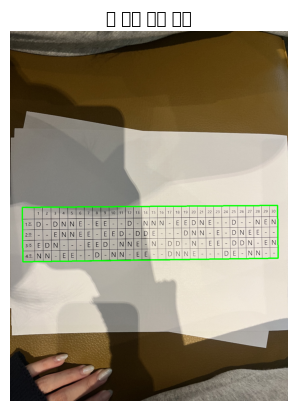

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
from google.colab import files

img_path = "/content/schedule9.jpeg"
image = cv2.imread(img_path)

if image is None:
    raise FileNotFoundError(f"이미지를 불러올 수 없습니다: {img_path}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("이미지 확인")
plt.axis('off')
plt.show()

# 크기 제한 (선택사항)
max_width = 1000
if image.shape[1] > max_width:
    scale = max_width / image.shape[1]
    image = cv2.resize(image, None, fx=scale, fy=scale)

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
thresh = cv2.adaptiveThreshold(
    blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 8
)

plt.imshow(thresh, cmap='gray')
plt.title("이진화된 이미지 (Adaptive Threshold)")
plt.axis('off')
plt.show()

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

table_contour = None
for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    if len(approx) == 4:
        table_contour = approx
        break

if table_contour is None:
    print("❌ 표를 찾지 못했습니다.")
else:
    temp = image.copy()
    cv2.drawContours(temp, [table_contour], -1, (0, 255, 0), 3)
    plt.imshow(temp)
    plt.title("표 외곽 검출 결과")
    plt.axis('off')
    plt.show()

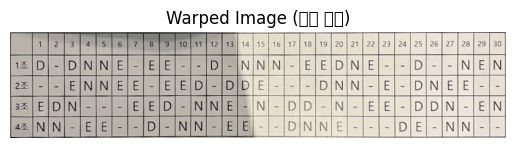

In [27]:
def sort_points(pts):
    pts = pts.reshape(4, 2)
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left
    return rect

# 정렬 좌표 계산
rect = sort_points(table_contour)
(tl, tr, br, bl) = rect
widthA = np.linalg.norm(br - bl)
widthB = np.linalg.norm(tr - tl)
maxWidth = max(int(widthA), int(widthB))
heightA = np.linalg.norm(tr - br)
heightB = np.linalg.norm(tl - bl)
maxHeight = max(int(heightA), int(heightB))

# Warp
dst = np.array([[0, 0], [maxWidth - 1, 0],
                [maxWidth - 1, maxHeight - 1], [0, maxHeight - 1]], dtype="float32")
M = cv2.getPerspectiveTransform(rect, dst)
warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

plt.imshow(warped)
plt.title("Warped Image (정렬 완료)")
plt.axis('off')
plt.show()


In [23]:
# ─────────────────────────────
# 셀 crop + 리사이즈 함수
# ─────────────────────────────
def tight_crop_and_resize(cell_img, out_size=(32,32)):
    if cell_img is None or cell_img.size == 0:
        return np.full(out_size, 255, dtype=np.uint8)
    _, threshed = cv2.threshold(cell_img, 200, 255, cv2.THRESH_BINARY)
    inv = 255 - threshed
    coords = cv2.findNonZero(inv)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped = cell_img[y:y+h, x:x+w]
    else:
        cropped = cell_img
    resized = cv2.resize(cropped, out_size)
    return resized


# ─────────────────────────────
# 셀 단일 분류 함수 (TFLite 기반)
# ─────────────────────────────
def classify_dne(cell_img, interpreter, input_details, output_details, debug=False, r=0, c=0):
    tight_img = tight_crop_and_resize(cell_img)
    white_ratio = np.mean(tight_img > 220)
    if debug:
        cv2.imwrite(f'debug_cell_r{r}_c{c}.png', tight_img)
    if white_ratio > WHITE_THRESH:
        if debug: print("Blank cell detected: white_ratio=", white_ratio)
        return '-'
    h, w = input_details[0]['shape'][1:3]
    inp = tight_img.astype(np.float32) / 255.0
    sample = inp.reshape(1, h, w, 1)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])[0]
    if debug: print(f"Probabilities: D={out[0]:.3f}, N={out[1]:.3f}, E={out[2]:.3f}")
    idx = np.argmax(out)
    label = CLASS_LABELS[idx]
    if debug: print("Predicted label:", label)
    return label


# ─────────────────────────────
# 메인 실행 함수 (전체 파이프라인)
# ─────────────────────────────
def main():
    # (1) 셀 경계 자동 추출 및 왜곡 보정
    img, data_rows, data_cols = get_table_cells(
        IMAGE_PATH, header_skip_y=HEADER_SKIP_Y, header_skip_x=HEADER_SKIP_X,
        vis_path="table_detected4.png"
    )

    # (2) TFLite 모델 준비
    interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)
    interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # (3) 셀 순회하며 분류
    result = {}
    debug_count = 0
    for r, (y1, y2) in enumerate(data_rows):
        row_dict = {}
        for c, (x1, x2) in enumerate(data_cols):
            cell_img = img[y1:y2, x1:x2]
            debug = (debug_count < 30)
            val = classify_dne(cell_img, interpreter, input_details, output_details,
                               debug=debug, r=r, c=c)
            row_dict[str(c+1)] = val
            if debug: debug_count += 1
        result[str(r+1)] = row_dict

    # (4) JSON 저장
    json_str = json.dumps(result, ensure_ascii=False, indent=2)
    print(json_str)
    with open('schedule_inferred4.json', 'w', encoding='utf-8') as f:
        f.write(json_str)
    print("✅ schedule_inferred4.json 생성 완료")


# ─────────────────────────────
# 실행
# ─────────────────────────────
if __name__ == '__main__':
    main()


Table lines visualization saved: table_detected4.png
Probabilities: D=1.000, N=0.000, E=0.000
Predicted label: D
Blank cell detected: white_ratio= 0.9228515625
Probabilities: D=1.000, N=0.000, E=0.000
Predicted label: D
Probabilities: D=0.000, N=1.000, E=0.000
Predicted label: N
Probabilities: D=0.000, N=1.000, E=0.000
Predicted label: N
Probabilities: D=0.000, N=0.000, E=1.000
Predicted label: E
Blank cell detected: white_ratio= 0.923828125
Probabilities: D=0.000, N=0.000, E=1.000
Predicted label: E
Probabilities: D=0.000, N=0.000, E=1.000
Predicted label: E
Blank cell detected: white_ratio= 0.890625
Blank cell detected: white_ratio= 0.8935546875
Probabilities: D=1.000, N=0.000, E=0.000
Predicted label: D
Blank cell detected: white_ratio= 0.8935546875
Probabilities: D=0.000, N=1.000, E=0.000
Predicted label: N
Probabilities: D=0.000, N=1.000, E=0.000
Predicted label: N
Probabilities: D=0.000, N=1.000, E=0.000
Predicted label: N
Blank cell detected: white_ratio= 0.923828125
Probabiliti